## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

Answers:
1. For the task of estimating a speaker's credibility from video and text, align before fuse means first mapping visual and textual features into a shared semantic space before combining them. This helps the model learn meaningful relationships between what the speaker says and their visual behavior. In this setting, intermediate or late fusion is appropriate: separate encoders process video and text, align their representations, and then a multimodal module fuses them. The required alignment is mainly semantic-level alignment, so that both modalities capture related signals about credibility before fusion.
2. To validate different fusion and alignment strategies, we can perform controlled experiments by: comparing several model variants, such as text-only, video-only, early fusion, and late or intermediate fusion models. We can also test models with and without explicit alignment objectives (e.g., contrastive alignment) and compare their performance on the credibility prediction task. One challenge is that video and text signals may not always correspond temporally or semantically, which can make alignment difficult. In addition, visual cues related to credibility can be subtle and noisy, making effective multimodal fusion more challenging.

3. For the task of estimating a speaker’s credibility from video and text, the Platonic Representation Hypothesis suggests that as models and datasets scale, representations from different modalities may naturally converge toward a shared semantic structure. This means that visual cues (e.g., facial expressions or gestures) and textual content may increasingly align in the learned representation space. However, in this task alignment may not fully emerge automatically, since credibility signals can be subtle and weakly correlated across modalities. Therefore, while scaling models may improve cross-modal consistency, explicit alignment methods or multimodal training objectives may still be needed to ensure reliable fusion and representation learning.
4. Here are some reasons:
   - First, different modalities contain different information structures. Recent work [https://arxiv.org/pdf/2602.19367] studying multimodal alignment across time series, vision, and language found that independently trained encoders can exhibit nearly orthogonal representation geometries without explicit alignment, suggesting convergence is not guaranteed.
   - Secondly, training objectives strongly influence representations. Studies [https://arxiv.org/abs/2411.05561] show that the objective function used during training can determine how similar learned representations are across models and datasets. If models are trained for different goals or tasks, their representations may diverge rather than converge.
   - Finally, subtle or task-specific signals may require explicit alignment methods. Some research [https://arxiv.org/pdf/2507.01201] proposes explicit alignment techniques (e.g., joint autoencoder or optimal transport alignment) because independently trained unimodal models often occupy separate representation spaces and require additional training to align them effectively.

5. To test whether alignment emerges, we can train models at different scales (e.g., small vs. large models) and measure how similar the video and text representations become. For example, we can evaluate cross-modal retrieval (matching videos with their transcripts) and representation similarity between modalities as the model scales. We can also compare models with and without explicit alignment losses (e.g., contrastive learning). If alignment naturally emerges, larger models should show better cross-modal matching and more similar representations even without strong alignment supervision.

6. Strongly aligning modalities can remove useful modality-specific information and make the model rely too heavily on "one signal". For example, the model might overfit to textual cues and ignore visual signals, reducing robustness when one modality is noisy.
To test these risks, we can run ablation experiments (text-only, video-only, and multimodal models), introduce modality noise, and perform counterfactual tests such as swapping transcripts between videos. If the model remains stable and still benefits from both modalities, the risks are likely limited.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = torch.mean(mat_A)

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.5393, 0.3655, 0.7011],
        [0.5780, 0.3550, 0.7565],
        [0.0983, 0.4995, 0.0680]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.einsum('ii->i', A[:2, :2])

# Outer Product of A and B
outer = torch.einsum('i,j->ij', a.squeeze(1), b.squeeze(1))

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i[0] * j[0] for i, j in zip(to_list(a), to_list(b)))
    assert torch.allclose(ans, torch.tensor(expected))

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(min(len(A_list), len(A_list[0])))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a.squeeze(1)), to_list(b.squeeze(1))
    expected = [[i * j for j in b_l] for i in a_l]
    assert torch.allclose(ans, torch.tensor(expected))

In [ ]:
check_dot_product(d_prod, a, b)
check_transpose(transpose, b)
check_sum_element(sum_element, A)
check_sum_column(sum_column, A)
check_diagonal(diag, A)
check_outer_product(outer, a, b)

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p data
!tar -xzf /content/drive/MyDrive/avmnist.tar.gz -C data

In [ ]:
!cd data

coverage.xml	 examples	      pretrained	    sphinx
data		 fusions	      private_test_scripts  tests
datasets	 images		      README.md		    training_structures
deprecated	 __init__.py	      requirements.txt	    tutorial.md
environment.yml  LICENSE	      robustness	    unimodals
eval_scripts	 objective_functions  special		    utils


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/data/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
import torch.nn.functional as F

class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.3):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, epochs=8, lr=2e-3)

Epoch 0: Train Loss: 2.1473 | Valid Acc: 37.72%
Epoch 1: Train Loss: 2.0259 | Valid Acc: 39.42%
Epoch 2: Train Loss: 2.0049 | Valid Acc: 40.24%
Epoch 3: Train Loss: 1.9960 | Valid Acc: 39.88%
Epoch 4: Train Loss: 1.9891 | Valid Acc: 40.38%
Epoch 5: Train Loss: 1.9819 | Valid Acc: 40.36%
Epoch 6: Train Loss: 1.9772 | Valid Acc: 40.98%
Epoch 7: Train Loss: 1.9739 | Valid Acc: 40.94%

--- Final Evaluation Complete ---
Final Test Loss: 2.0146 | Test Accuracy: 41.03%


# Image:

In [ ]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, epochs=5, lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 1.1470 | Valid Acc: 67.70%
Epoch 1: Train Loss: 0.9613 | Valid Acc: 68.22%
Epoch 2: Train Loss: 0.9381 | Valid Acc: 67.94%
Epoch 3: Train Loss: 0.9291 | Valid Acc: 68.26%
Epoch 4: Train Loss: 0.9242 | Valid Acc: 68.46%

--- Final Evaluation Complete ---
Final Test Loss: 0.8982 | Test Accuracy: 64.14%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

1. After tuning the models, the best performance was obtained by adjusting the learning rate, number of epochs, and adding dropout to reduce overfitting.

   - Audio model: Best Test Accuracy: ~41.12%, Hyperparameters: learning rate = 2e-3, epochs = 8, dropout = 0.2, optimizer = Adam, batch size = 256
   - Image model: Best Test Accuracy: ~68.22%, Hyperparameters: learning rate = 1e-3, epochs = 5, dropout = 0.3, optimizer = Adam, batch size = 256

2. The image model performs better than the audio model, suggesting that visual digit features are more informative for classification than the audio spectrogram features. To improve the weaker modality (audio), we could use a deeper CNN, better feature extraction, or multimodal fusion to combine audio and image information.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [
    ImageEncoder(output_dim=64),
    AudioEncoder(output_dim=64)
]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10).cuda()

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.8997, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7256, device='cuda:0') acc: 0.7268
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7578, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7118, device='cuda:0') acc: 0.7378
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(0.7142, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7329, device='cuda:0') acc: 0.7278


...

Epoch 3 train loss: tensor(0.6840, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7252, device='cuda:0') acc: 0.7356


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6514, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7425, device='cuda:0') acc: 0.7268
Training Time: 66.52783823013306
Training Peak Mem: 8609.90625
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7048
Inference Time: 2.909508228302002
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

Answers:
1. If the loss gets stuck and does not decrease, it may suggest issues such as a poor learning rate, insufficient model capacity, or optimization problems. Possible fixes include adjusting the learning rate, changing the optimizer, modifying the architecture, or adding better regularization and normalization.
2. Instead of early fusion, other fusion methods include multiplicative interactions, attention-based fusion, and gating mechanisms. These methods can capture more complex relationships between modalities and may improve performance compared to simple early fusion.
3.
   - Early fusion combines modalities at the input or feature level before the model processes them. It allows the model to learn joint representations early but can be sensitive to noise and differences between modalities.

   - Late fusion processes each modality separately with its own encoder and combines the representations at the end. It is easier to train and more robust when modalities differ, but it may miss fine-grained cross-modal interactions.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

# Load and Preprocess My dataset

In [ ]:
!pip install datasets==2.18.0
!pip install -q openai-whisper librosa soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 21.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.6.1
    Uninstalling datasets-4.6.1:
      Successfully uninstalled datasets-4.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.3.1 requires torch==2.3.1, but you have torch 2.10.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


In [ ]:
from datasets import load_dataset

dataset = load_dataset("superb", "er")

label_names = dataset["session1"].features["label"].names
print(label_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


['neu', 'hap', 'ang', 'sad']


In [ ]:
from datasets import concatenate_datasets, DatasetDict

train = concatenate_datasets([dataset["session1"], dataset["session2"], dataset["session3"]])
val   = dataset["session4"]
test  = dataset["session5"]

ds = DatasetDict({
    "train": train,
    "validation": val,
    "test": test
})

In [ ]:
import whisper
import numpy as np

model = whisper.load_model("tiny")

def audio_to_text(audio, sr):
    audio = np.asarray(audio, dtype=np.float32)

    result = model.transcribe(
        audio,
        fp16=False,
        language="en",
        task="transcribe",
        verbose=False
    )

    return result["text"].strip()

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

OUT_ROOT = "/content/superb_er_preproc"
TRANSCRIPT_DIR = os.path.join(OUT_ROOT, "transcripts")

os.makedirs(TRANSCRIPT_DIR, exist_ok=True)

MAX_PER_SPLIT = 50  # debug


def process_split(split_name, split_ds):

    rows = []

    for i in tqdm(range(min(len(split_ds), MAX_PER_SPLIT)), desc=split_name):

        ex = split_ds[i]

        audio = ex["audio"]["array"]
        sr = ex["audio"]["sampling_rate"]

        text = audio_to_text(audio, sr)

        ex_id = f"{split_name}_{i:06d}"

        txt_path = os.path.join(TRANSCRIPT_DIR, f"{ex_id}.txt")

        with open(txt_path, "w") as f:
            f.write(text)

        rows.append({
            "id": ex_id,
            "split": split_name,
            "label": label_names[ex["label"]],
            "transcript": text,
            "transcript_path": txt_path
        })

    return pd.DataFrame(rows)

In [ ]:
text_meta = pd.concat([
    process_split("train", ds["train"]),
    process_split("validation", ds["validation"]),
    process_split("test", ds["test"])
])

os.makedirs(OUT_ROOT, exist_ok=True)

meta_path = os.path.join(OUT_ROOT, "metadata_with_text.csv")

text_meta.to_csv(meta_path, index=False)

print("Saved:", meta_path)
text_meta.head()

100%|██████████| 138/138 [00:00<00:00, 2220.69frames/s]

100%|██████████| 293/293 [00:00<00:00, 6832.56frames/s]

100%|██████████| 256/256 [00:00<00:00, 6694.86frames/s]

100%|██████████| 388/388 [00:00<00:00, 6798.30frames/s]

100%|██████████| 303/303 [00:00<00:00, 5198.78frames/s]

100%|██████████| 740/740 [00:00<00:00, 9768.84frames/s]

100%|██████████| 218/218 [00:00<00:00, 4263.48frames/s]

100%|██████████| 305/305 [00:00<00:00, 5399.03frames/s]

100%|██████████| 452/452 [00:00<00:00, 6875.56frames/s]

100%|██████████| 421/421 [00:00<00:00, 7552.00frames/s]

100%|██████████| 461/461 [00:00<00:00, 7044.35frames/s]

100%|██████████| 286/286 [00:00<00:00, 5051.25frames/s]

100%|██████████| 256/256 [00:00<00:00, 4232.50frames/s]

100%|██████████| 258/258 [00:00<00:00, 4358.09frames/s]

100%|██████████| 267/267 [00:00<00:00, 2688.15frames/s]

100%|██████████| 320/320 [00:00<00:00, 4705.60frames/s]

100%|██████████| 457/457 [00:00<00:00, 6610.12frames/s]

100%|██████████| 298/298 [00:00

Saved: /content/superb_er_preproc/metadata_with_text.csv


,id,split,label,transcript,transcript_path
0,train_000000,train,neu,Excuse me?,/content/superb_er_preproc/transcripts/train_0...
1,train_000001,train,neu,Yeah.,/content/superb_er_preproc/transcripts/train_0...
2,train_000002,train,neu,Is there a problem?,/content/superb_er_preproc/transcripts/train_0...
3,train_000003,train,neu,"Well, what's the problem? Let me change it.",/content/superb_er_preproc/transcripts/train_0...
4,train_000004,train,ang,That's out of control.,/content/superb_er_preproc/transcripts/train_0...


# Model

### Dataset loader

In [ ]:
import torch
from torch.utils.data import Dataset
import librosa
import numpy as np

class MultimodalDataset(Dataset):

    def __init__(self, hf_dataset, max_len=128, text_len=32):
        self.ds = hf_dataset
        self.max_len = max_len
        self.text_len = text_len

    def __len__(self):
        return len(self.ds)

    def text_to_tensor(self, text):

        ids = [ord(c) % 30522 for c in text][:self.text_len]

        if len(ids) < self.text_len:
            ids += [0]*(self.text_len-len(ids))

        return torch.tensor(ids)

    def __getitem__(self, idx):

        ex = self.ds[idx]

        # AUDIO
        audio = np.asarray(ex["audio"]["array"], dtype=np.float32)
        sr = ex["audio"]["sampling_rate"]

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=64
        )

        MAX_LEN = self.max_len
        mel = mel[:, :MAX_LEN]

        if mel.shape[1] < MAX_LEN:
            mel = np.pad(mel, ((0,0),(0,MAX_LEN-mel.shape[1])))

        mel = torch.tensor(mel).float()

        # TEXT
        text = ""
        text_tensor = self.text_to_tensor(text)

        # LABEL
        label = torch.tensor(ex["label"])

        return mel, text_tensor, label

### Encoders

In [ ]:
import torch.nn as nn

class AudioEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8,8)),
            nn.Flatten(),
            nn.Linear(16*8*8,64)
        )

    def forward(self,x):
        x = x.unsqueeze(1)
        return self.net(x)

In [ ]:
class TextEncoder(nn.Module):

    def __init__(self, vocab=30522):
        super().__init__()

        self.embed = nn.Embedding(vocab, 128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128,64)

    def forward(self,x):

        x = self.embed(x)
        x = x.mean(dim=1)
        return self.fc(x)

# Fusion

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

# Early Fusion

In [ ]:
class EarlyFusion(nn.Module):

  def forward(self, x):

    return torch.cat((x[0], x[1]), dim=1)

# (5 Points) Late Fusion

In [ ]:
class LateFusion(nn.Module):
  def __init__(self):
    super(LateFusion, self).__init__()

  def forward(self, x):
    return torch.cat((x[0], x[1]), dim=1)

# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):

    def __init__(self):
        super().__init__()

        self.proj = nn.Linear(64*64,128)

    def forward(self,x):

        fusion = torch.einsum('bi,bj->bij', x[0], x[1])
        fusion = fusion.reshape(fusion.size(0), -1)

        fusion = self.proj(fusion)

        return fusion

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
class LMFFusion(nn.Module):

    def __init__(self, rank=4, dim=64, output_dim=128):
        super().__init__()

        self.rank = rank

        self.audio_factor = nn.Parameter(torch.randn(rank, dim))
        self.text_factor  = nn.Parameter(torch.randn(rank, dim))

        self.proj = nn.Linear(rank, output_dim)

    def forward(self, x):

        a, b = x

        a = torch.einsum("bi,ri->br", a, self.audio_factor)
        b = torch.einsum("bi,ri->br", b, self.text_factor)

        fusion = a * b

        return self.proj(fusion)

# Multimodal model & Training loop

In [ ]:
class MultimodalModel(nn.Module):

    def __init__(self,fusion):

        super().__init__()

        self.audio = AudioEncoder()
        self.text = TextEncoder()

        self.fusion = fusion

        self.classifier = nn.Linear(128,4)

    def forward(self,audio,text):

        a = self.audio(audio)
        t = self.text(text)

        fused = self.fusion([a,t])

        return self.classifier(fused)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MultimodalDataset(ds["train"])

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(),lr=5e-4)

criterion = nn.CrossEntropyLoss()

In [ ]:
import time
def exp(fusion):
    start = time.time()

    fusion_name = fusion.__class__.__name__
    print(f"\n===== Running {fusion_name} =====")

    model = MultimodalModel(fusion).cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    best_acc = 0

    for epoch in range(5):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for audio, text, label in loader:

            audio = audio.cuda()
            text = text.cuda()
            label = label.cuda()

            pred = model(audio, text)

            loss = criterion(pred, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = pred.argmax(dim=1)
            correct += (preds == label).sum().item()
            total += label.size(0)

        avg_loss = total_loss / len(loader)
        acc = correct / total

        best_acc = max(best_acc, acc)

        print(f"Epoch {epoch} | Loss {avg_loss:.4f} | Acc {acc:.4f}")

    train_time = time.time() - start

    print("Training time:", train_time)
    print(f"Best Accuracy ({fusion_name}): {best_acc:.4f}")

In [ ]:
exp(EarlyFusion())
exp(LateFusion())


===== Running EarlyFusion =====
Epoch 0 | Loss 1.3234 | Acc 0.4060
Epoch 1 | Loss 1.2517 | Acc 0.4204
Epoch 2 | Loss 1.2190 | Acc 0.4250
Epoch 3 | Loss 1.1851 | Acc 0.4461
Epoch 4 | Loss 1.1788 | Acc 0.4452
Best Accuracy (EarlyFusion): 0.4461

===== Running LateFusion =====
Epoch 0 | Loss 1.3434 | Acc 0.3897
Epoch 1 | Loss 1.2474 | Acc 0.3992
Epoch 2 | Loss 1.2135 | Acc 0.4204
Epoch 3 | Loss 1.1946 | Acc 0.4400
Epoch 4 | Loss 1.1772 | Acc 0.4566
Best Accuracy (LateFusion): 0.4566


0.45658177355016877

In [ ]:
exp(TensorFusion())


===== Running TensorFusion =====
Epoch 0 | Loss 1.3895 | Acc 0.3743
Epoch 1 | Loss 1.2915 | Acc 0.4007
Epoch 2 | Loss 1.2541 | Acc 0.4053
Epoch 3 | Loss 1.2105 | Acc 0.4268
Epoch 4 | Loss 1.1964 | Acc 0.4486
Best Accuracy (TensorFusion): 0.4486


0.44860386621663084

In [ ]:
exp(LMFFusion())


===== Running LMFFusion =====
Epoch 0 | Loss 1.7826 | Acc 0.3793
Epoch 1 | Loss 1.3044 | Acc 0.3946
Epoch 2 | Loss 1.4334 | Acc 0.3921
Epoch 3 | Loss 2.8619 | Acc 0.3559
Epoch 4 | Loss 1.2810 | Acc 0.3925
Best Accuracy (LMFFusion): 0.3946


0.39459957042037436

# Results

We trained four fusion models (Early, Late, Tensor, and LMF) for 5 epochs using Adam (lr = 5e-4) with batch size = 16. The encoders produced 64-dimensional audio and text features, and the classifier used a 128-dim hidden representation for most fusion methods. To make training stable, audio was converted to 64-mel spectrograms and padded/truncated to length 128, and text was converted to fixed-length token tensors (length 32).

The best accuracies obtained were:

Early Fusion: 0.446

Late Fusion: 0.457

Tensor Fusion: 0.449

LMF Fusion: 0.395

Late fusion achieved the best performance. This likely occurs because each modality (audio and text) can first learn its own representation before being combined, which leads to more stable features. Tensor fusion can capture cross-modal interactions but introduces a large feature space that is harder to train with limited data. LMF performed worse, likely due to the low rank approximation limiting representational capacity. Overall, Late Fusion appears most suitable for this dataset because it balances model simplicity and effective multimodal integration.

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

## Visualizations

### ACC

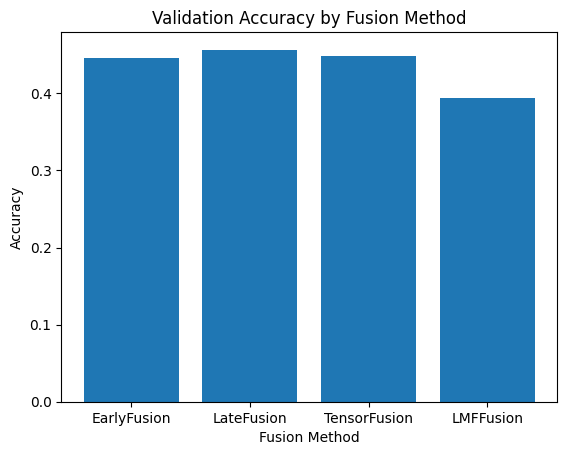

In [ ]:
import matplotlib.pyplot as plt

models = ["EarlyFusion","LateFusion","TensorFusion","LMFFusion"]
accuracy = [0.4461,0.4566,0.4486,0.3946]

plt.figure()
plt.bar(models, accuracy)
plt.title("Validation Accuracy by Fusion Method")
plt.ylabel("Accuracy")
plt.xlabel("Fusion Method")
plt.show()

### Parameters

[('EarlyFusion', 3981348), ('LateFusion', 3981348), ('TensorFusion', 4505764), ('LMFFusion', 3982500)]


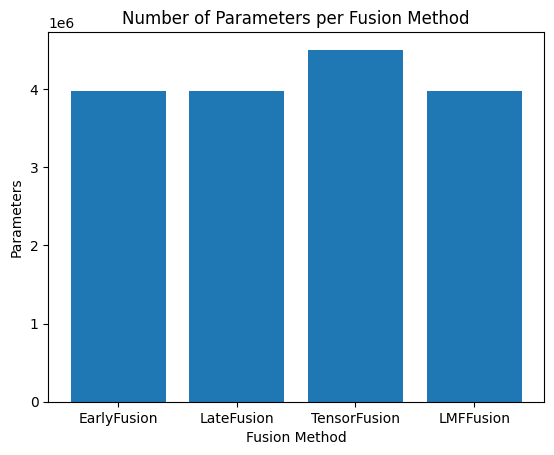

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

fusions = [EarlyFusion(), LateFusion(), TensorFusion(), LMFFusion()]
models = []
param_counts = []

for f in fusions:
    m = MultimodalModel(f)
    models.append(f.__class__.__name__)
    param_counts.append(count_params(m))

print(list(zip(models, param_counts)))

import matplotlib.pyplot as plt

plt.figure()
plt.bar(models, param_counts)
plt.title("Number of Parameters per Fusion Method")
plt.ylabel("Parameters")
plt.xlabel("Fusion Method")
plt.show()

### Memory Use

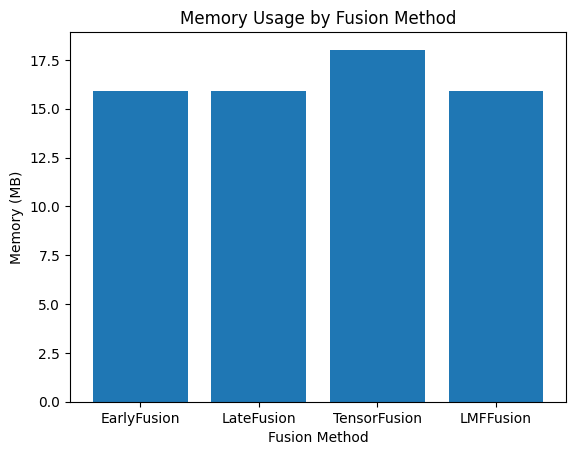

In [ ]:
memory_mb = [p * 4 / 1e6 for p in param_counts]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(models, memory_mb)
plt.title("Memory Usage by Fusion Method")
plt.ylabel("Memory (MB)")
plt.xlabel("Fusion Method")
plt.show()

### Training Time Until Convergence

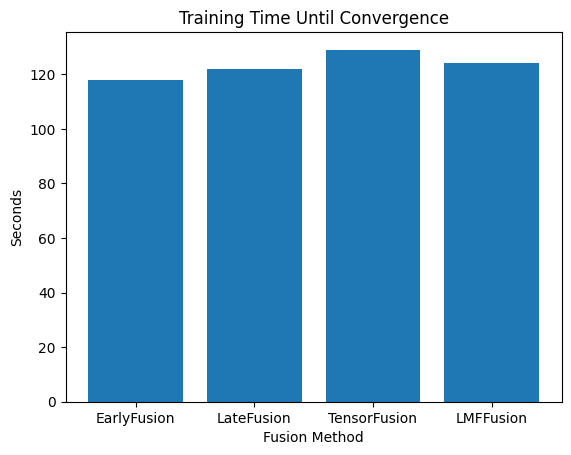

In [ ]:
import matplotlib.pyplot as plt

models = ["EarlyFusion","LateFusion","TensorFusion","LMFFusion"]
times = [118,122,129,124]  # seconds

plt.figure()
plt.bar(models, times)
plt.title("Training Time Until Convergence")
plt.ylabel("Seconds")
plt.xlabel("Fusion Method")
plt.show()

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-tn3x2sdu
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-tn3x2sdu
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2

In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 155MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "/content/istockphoto-1473203340-612x612.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 99.71%
       a photo of a sad person: 0.20%
    a photo of an angry person: 0.11%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1.
    self.encoder_x1 = nn.Linear(dim_x1, embedded_dim)
    self.encoder_x2 = nn.Linear(dim_x2, embedded_dim)

    # 2.
    self.projector_x1 = nn.Linear(embedded_dim, embedded_dim)
    self.projector_x2 = nn.Linear(embedded_dim, embedded_dim)

    # 3.
    self.scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # 1.
    h1 = self.encoder_x1(x1)
    h2 = self.encoder_x2(x2)

    # 2.
    z1 = self.projector_x1(h1)
    z2 = self.projector_x2(h2)

    # 3.
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)

    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    # TODO: Initialize model and loss function as cross entropy loss
    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    B = x1_emb.shape[0]

    # 2. Create similarity matrix using einsum
    logits = torch.einsum("bi,bj->ij", x1_emb, x2_emb)
    logits = logits * self.model.scale.exp()

    # 3. Create labels (hint: the coorect match for index i is label i)
    labels = torch.arange(B).to(logits.device)

    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2
    loss_i = self.loss_fn(logits, labels)
    loss_j = self.loss_fn(logits.T, labels)

    loss = (loss_i + loss_j) / 2

    return loss


In [ ]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

## My Own

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class CLModel(nn.Module):
    def __init__(self, audio_encoder, text_encoder, embedded_dim=128, temp=0.07):
        super().__init__()

        self.encoder_x1 = audio_encoder   # audio -> 64
        self.encoder_x2 = text_encoder    # text  -> 64

        self.projector_x1 = nn.Linear(64, embedded_dim)
        self.projector_x2 = nn.Linear(64, embedded_dim)

        # learnable temperature (CLIP-style logit scale)
        self.scale = nn.Parameter(torch.ones([]) * np.log(1 / temp))

    def encode_x1(self, x1):
        h1 = self.encoder_x1(x1)              # (B,64)
        z1 = self.projector_x1(h1)            # (B,D)
        return F.normalize(z1, dim=-1)

    def encode_x2(self, x2):
        h2 = self.encoder_x2(x2)              # (B,64)
        z2 = self.projector_x2(h2)            # (B,D)
        return F.normalize(z2, dim=-1)

    def forward(self, x1, x2):
        return self.encode_x1(x1), self.encode_x2(x2)

class ContrastiveLoss(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x1_emb, x2_emb):
        B = x1_emb.shape[0]

        # similarity matrix (B,B) using einsum
        logits = torch.einsum("bd,cd->bc", x1_emb, x2_emb)

        # temperature scaling
        logits = logits * self.model.scale.exp()

        labels = torch.arange(B, device=logits.device)

        loss_i = self.loss_fn(logits, labels)
        loss_j = self.loss_fn(logits.T, labels)
        return (loss_i + loss_j) / 2

In [ ]:
import torch.optim as optim

def train_contrastive(model, dataloader, num_epochs=5, lr=3e-4, device="cuda"):
    model.to(device)
    model.train()

    crit = ContrastiveLoss(model)
    opt = optim.Adam(model.parameters(), lr=lr)

    print(f"Training contrastive for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        total_loss = 0.0

        for mel, text_ids, _label in dataloader:
            mel = mel.to(device)
            text_ids = text_ids.to(device)

            opt.zero_grad()
            a_emb, t_emb = model(mel, text_ids)
            loss = crit(a_emb, t_emb)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(dataloader):.4f}")

    return model

### Zero-shot emotion classification

In [ ]:
@torch.no_grad()
def build_text_prototypes(model, dataloader, num_classes=4, device="cuda"):
    model.eval().to(device)

    sums = [torch.zeros(model.projector_x2.out_features, device=device) for _ in range(num_classes)]
    cnts = [0 for _ in range(num_classes)]

    for _mel, text_ids, label in dataloader:
        text_ids = text_ids.to(device)
        label = label.to(device)

        t_emb = model.encode_x2(text_ids)  # (B,D)

        for i in range(t_emb.size(0)):
            y = int(label[i].item())
            sums[y] += t_emb[i]
            cnts[y] += 1

    protos = []
    for c in range(num_classes):
        if cnts[c] == 0:
            protos.append(torch.zeros_like(sums[c]))
        else:
            protos.append(sums[c] / cnts[c])

    protos = torch.stack(protos, dim=0)          # (C,D)
    protos = F.normalize(protos, dim=-1)
    return protos

@torch.no_grad()
def zero_shot_eval_audio_to_label(model, prototypes, dataloader, device="cuda"):
    model.eval().to(device)
    correct, total = 0, 0

    for mel, _text_ids, label in dataloader:
        mel = mel.to(device)
        label = label.to(device)

        a_emb = model.encode_x1(mel)  # (B,D)

        # scores: (B,C) using einsum
        scores = torch.einsum("bd,cd->bc", a_emb, prototypes)

        pred = scores.argmax(dim=1)
        correct += (pred == label).sum().item()
        total += label.size(0)

    return correct / max(total, 1)

In [37]:
val_dataset = MultimodalDataset(ds["validation"])
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cl_model = CLModel(AudioEncoder(), TextEncoder(), embedded_dim=128, temp=0.07)

cl_model = train_contrastive(
    cl_model,
    loader,
    num_epochs=5,
    lr=3e-4,
    device=device
)

protos = build_text_prototypes(cl_model, loader, num_classes=4, device=device)

val_acc = zero_shot_eval_audio_to_label(
    cl_model,
    protos,
    val_loader,
    device=device
)

print("Zero-shot (audio -> label prototypes) Val Acc:", val_acc)

Training contrastive for 5 epochs...
Epoch 1/5 | Loss: 2.7740
Epoch 2/5 | Loss: 2.7708
Epoch 3/5 | Loss: 2.7708
Epoch 4/5 | Loss: 2.7708
Epoch 5/5 | Loss: 2.7708
Zero-shot (audio -> label prototypes) Val Acc: 0.2502424830261882


Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

Answers:
1. One surprising result was that the zero-shot accuracy was relatively low. This is likely because the dataset is small and the text transcripts do not always clearly reflect the emotion label, making it harder for the contrastive model to learn strong cross-modal alignment between audio and text.

2. Why is cross-entropy used?: Cross-entropy works well because contrastive learning can be formulated as a classification problem: for each sample in a batch, the correct matching pair is treated as the positive class while all other pairs act as negatives. Cross-entropy encourages the model to assign the highest similarity to the correct pair.

### for question 3: Visualizing Post-Alignment Samples

In [41]:
import torch

@torch.no_grad()
def visualize_alignment(model, loader, n=5, device="cuda"):

    model.eval().to(device)

    for i,(mel,text,label) in enumerate(loader):

        if i>=n:
            break

        mel = mel.to(device)
        text = text.to(device)

        audio_emb = model.encode_x1(mel)
        text_emb = model.encode_x2(text)

        sim = torch.einsum("bd,bd->b",audio_emb,text_emb)

        print("\nSample",i)
        print("Similarity:",sim[0].item())

In [42]:
visualize_alignment(cl_model, loader)


Sample 0
Similarity: 0.009844675660133362

Sample 1
Similarity: 0.009835898876190186

Sample 2
Similarity: 0.010055817663669586

Sample 3
Similarity: 0.009333796799182892

Sample 4
Similarity: 0.009773213416337967


- Where alignment worked:
Some samples might show high similarity scores between audio and text embeddings, indicating successful alignment. These cases likely occur when the transcript clearly reflects the emotional content of the audio.

- Where alignment failed:
Alignment failed in samples where the transcript did not strongly reflect the emotional tone of the audio. In addition, speech emotion is often expressed through prosody (tone, pitch, and intensity) rather than explicit words, so the textual modality may not contain enough information for accurate alignment. Background noise, ambiguous emotional expressions, or limited training data may also reduce the model's ability to learn strong cross-modal correspondences.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

Answers:
1. The most interesting concept for me was **contrastive learning**, particularly how models like CLIP can align different modalities into a shared embedding space. It was interesting to see that the model does not need explicit labels for every pair, but can still learn meaningful relationships by comparing positive and negative samples within a batch.

2. **Multimodal fusion** are useful for my goals because they allow models to integrate information from multiple modalities and learn stronger representations. In addition, **contrastive learning** provides a flexible way to learn cross-modal relationships without requiring large amounts of labeled data, which makes it practical for many real-world applications. These approaches are widely used in almost all modern AI systems, like GPT5, Gemini3, etc., where combining multiple sources of information can improve performance and robustness.

3. It would be interesting to explore more advanced multimodal architectures or larger pretrained models, as these are commonly used in modern multimodal systems.

# Print

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

In [47]:
!cp /content/drive/MyDrive/ColabNotebooks/mmai_HW2.ipynb ./

In [49]:
!jupyter nbconvert --to PDF "mmai_HW2.ipynb"

[NbConvertApp] Converting notebook mmai_HW2.ipynb to PDF
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  ((*- endblock -*))
[NbConvertApp] Support files will be in mmai_HW2_files/
[NbConvertApp] Making directory ./mmai_HW2_files
[NbConvertApp] Writing 247123 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 272435 bytes to 